In [1]:
# Importing the necessary library
import numpy as np
import matplotlib.pyplot as plt
from numpy import random
import torch
import torch.nn as nn
import re
from huggingface_hub import hf_hub_download
from datasets import load_dataset
from torch.distributions.categorical import Categorical
from torch.utils.data import Dataset
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from collections import Counter
from collections import OrderedDict

In [ ]:
# Creating a RNN layer in Pytorch.nn
torch.manual_seed(1)
rnn_layer=nn.RNN(input_size=5,hidden_size=2,num_layers=1,batch_first=True)
w_xh=rnn_layer.weight_ih_l0
w_hh=rnn_layer.weight_hh_l0
b_xh=rnn_layer.bias_ih_l0
b_hh=rnn_layer.bias_hh_l0
print('W_xh shape',w_xh.shape)
print('W_hh shape',w_hh.shape)
print('b_xh shape',b_xh.shape)
print('b_hh shape',b_hh.shape)

# Forward passing the sequence and computing outputs at each step
x_seq=torch.tensor([[1.0]*5,[2.0]*5,[3.0]*5])
# output of the simple RNN
output,hn=rnn_layer(x_seq.reshape(1,3,5))
# manually computing the output
out_man=[]
for t in range(3):
    xt=torch.reshape(x_seq[t],(1,5))
    print(f'Time step {t} =>')
    print('    Input      :',xt.numpy())
    ht=torch.matmul(xt,torch.transpose(w_xh,0,1))+b_hh
    print('   Hidden    :',ht.detach().numpy())
    if t>0:
        prev_hist=out_man[t-1]
    else:
        prev_h=torch.zeros((ht.shape))
    ot = ht + torch.matmul(prev_h, torch.transpose(w_hh, 0, 1)) + b_hh
    ot = torch.tanh(ot)
    out_man.append(ot)
    print(' Output (manual) :', ot.detach().numpy())
    print(' RNN output :', output[:, t].detach().numpy())
    print()

W_xh shape torch.Size([2, 5])
W_hh shape torch.Size([2, 2])
b_xh shape torch.Size([2])
b_hh shape torch.Size([2])
Time step 0 =>
    Input      : [[1. 1. 1. 1. 1.]]
   Hidden    : [[-0.3161478  0.6472246]]
 Output (manual) : [[-0.21046415  0.5678879 ]]
 RNN output : [[-0.35198015  0.52525216]]

Time step 1 =>
    Input      : [[2. 2. 2. 2. 2.]]
   Hidden    : [[-0.73478645  1.297274  ]]
 Output (manual) : [[-0.5596309   0.86028737]]
 RNN output : [[-0.68424344  0.76074266]]

Time step 2 =>
    Input      : [[3. 3. 3. 3. 3.]]
   Hidden    : [[-1.153425   1.9473233]]
 Output (manual) : [[-0.7821692  0.9598892]]
 RNN output : [[-0.8649416   0.90466356]]



In [ ]:
# Training dataset
ds_train = load_dataset("stanfordnlp/imdb",split="train").with_format("torch")
# Test dataset
ds_test = load_dataset("stanfordnlp/imdb",split="test").with_format("torch")

# Subsetting train and validation sets from the train dataset
torch.manual_seed(44)
test_text=ds_test['text']
test_label=ds_test['label']
train_text,valid_text=random_split(ds_train['text'],[20000,5000])
train_lab,valid_lab=random_split(ds_train['label'],[20000,5000])
# Zipping the data, so that we have text and labels together
train_data=zip(train_text,train_lab)
valid_data=zip(valid_text,valid_lab)
test_data=zip(test_text,test_label)

# Finding unique tokens (words)
def tokenizer(text):
    # Removing HTML tags
    text=re.sub('<[^>]*>','',text)
    # Finding all emoticons
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
    # Replacing all non-word characters with spaces and making text lowercase
    # Appending the saved emoticons back to the end of the string
    text=re.sub('[\W]+', ' ',text.lower()) + (' ').join(emoticons).replace('-','')
    # Splitting the tockednized text
    tockenized=text.split()
    return tockenized

# Building the tockenizer
token_counts=Counter()
for line in train_text:
    tokens=tokenizer(line)
    token_counts.update(tokens)
print('Vocab size',len(token_counts)) # 69167 unique words

# Sorting the elements of the dictionary
# Using items to get the pair of keys+values; then employing the reverse sorting based on the frequency
sorted_by_freq=sorted(token_counts.items(),key=lambda x:x[1],reverse=True)
# Creating an ordered dictionary from the sorted tuples
order_by_freq=OrderedDict(sorted_by_freq)

# Assigning a random number to each of the words to create the embeddings
tok_dict={word:i+4 for i,word in enumerate(order_by_freq)}
# Adding unknown token and padding tokens
tok_dict.update({"<unk>":1})
tok_dict.update({"<pad>":0})
tok_dict.update({"<sos>":2})
tok_dict.update({"<eos>":3})

# Printing the random numbers assigned to several words
[tok_dict[wor] for wor in ['this','that','a','example']]


<>:22: SyntaxWarning: invalid escape sequence '\)'
<>:25: SyntaxWarning: invalid escape sequence '\W'
<>:22: SyntaxWarning: invalid escape sequence '\)'
<>:25: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_1570/3958158617.py:22: SyntaxWarning: invalid escape sequence '\)'
  emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
/tmp/ipykernel_1570/3958158617.py:25: SyntaxWarning: invalid escape sequence '\W'
  text=re.sub('[\W]+', ' ',text.lower()) + (' ').join(emoticons).replace('-','')
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access publi

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Vocab size 69461


[13, 14, 6, 450]

In [ ]:
len(tok_dict)

69465

In [ ]:
# Creating the text pipeline and the label pipeline
# Defining the functions for transformations
text_pipeline=lambda x: [tok_dict[word] if word in tok_dict.keys() else 1 for word in tokenizer(x)]
label_pipeline=lambda x: 1.0 if x=="pos" else 0.0

# Wrapping and encoding the transformation function
def collate_batch(batch):
    label_list,text_list,lengths=[],[],[]
    for _text,_lab in batch:
        label_list.append(label_pipeline(_lab))
        # Encoding the text snippets and converting them to tensors
        processed_text=torch.tensor(text_pipeline(_text)).squeeze()
        # Appending tensors to the list
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))
    # Creating a tensor from the labels
    label_list=torch.tensor(label_list)
    lengths=torch.tensor(lengths)
    # Stacking the list of tensors along a new dimension and padding them
    padded_text_list=nn.utils.rnn.pad_sequence(text_list,batch_first=True)
    return padded_text_list,label_list,lengths

# Creating a TensorDataset and TensorDataloader
train_text,train_label,train_lengths=collate_batch(train_data)
valid_text,valid_label,valid_lengths=collate_batch(valid_data)
test_text,test_label,test_lengths=collate_batch(test_data)

# Creating TensorDatasets and TensorDataloaders on the data
train_ds=TensorDataset(train_text,train_label)
valid_ds=TensorDataset(valid_text,valid_label)
test_ds=TensorDataset(test_text,test_label)

# Creating dataloaders from the tensordatasets
batch_size=32
train_dl=DataLoader(train_ds,batch_size=batch_size,shuffle=True)
valid_dl=DataLoader(valid_ds,batch_size=batch_size,shuffle=False)
test_dl=DataLoader(test_ds,batch_size=batch_size,shuffle=False)

In [ ]:
# Training the model
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Creating a class for RNN implementation on sentiment analysis
class LSTM(nn.Module):
    def __init__(self,vocab_size,embed_dim,rnn_hidden_size,fc_hidden_size):
        super().__init__()
        self.embedding=nn.Embedding(vocab_size,embed_dim,padding_idx=0)
        self.lstm=nn.LSTM(embed_dim,rnn_hidden_size,batch_first=True)
        self.fc1=nn.Linear(rnn_hidden_size,fc_hidden_size)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(fc_hidden_size,1)
        self.sigmoid=nn.Sigmoid()
    def forward(self,text):
        out=self.embedding(text)
        out,(hidden,cell)=self.lstm(out)
        out=hidden[-1,:,:]
        out=self.fc1(out)
        out=self.relu(out)
        out=self.fc2(out)
        out=self.sigmoid(out)
        return out

# Determining the vocab size
vocab_size=len(tok_dict)
emdedding_dim=10
rnn_hidden_size=64
fc_hidden_size=64
torch.manual_seed(1)
model=LSTM(vocab_size=len(tok_dict),embed_dim=10,rnn_hidden_size=64,fc_hidden_size=64)
model=model.to(device)
# Defining the optimizer and the loss function
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.BCELoss()

# Function for model training
def train(model,train_dl,valid_dl,epochs):
    train_loss=[0]*epochs
    train_acc=[0]*epochs
    val_loss=[0]*epochs
    val_acc=[0]*epochs
    for epoch in range(epochs):
        model.train()
        for text,lab in train_dl:
            text=text.to(device)
            lab=lab.to(device)
            # Reset the gradients after each training turn
            optimizer.zero_grad()
            pred=model(text).squeeze()
            loss=loss_fn(pred,lab)
            loss.backward()
            optimizer.step()
            # Stroring the loss during the training process
            train_loss[epoch]+=loss.item()
            # Storing the accuracy during the training process
            is_correct=((pred>=0.5).float()==lab).float()
            train_acc[epoch]+=is_correct.sum().item()
        # Normalizing the loss by the number of batches
        train_loss[epoch]/=len(train_dl)
        #Normalizing the accurary by the length of the dataset
        train_acc[epoch]/=len(train_dl.dataset)
        # Evaluation part
        model.eval()
        with torch.no_grad():
            for text,lab in valid_dl:
                text=text.to(device)
                lab=lab.to(device)
                pred=model(text).squeeze()
                loss=loss_fn(pred,lab)
                val_loss[epoch]+=loss.item()
                is_correct=((pred>=0.5).float()==lab).float()
                val_acc[epoch]+=is_correct.sum().item()
        # Normalizing the validation loss by the number of batches in the dataset
        val_loss[epoch]/=len(valid_dl)
        # Normalizing the validation accuracy by the number of objects in the dataset
        val_acc[epoch]/=len(valid_dl.dataset)
        print(f"{epoch}, Train Acc {train_acc[epoch]:.3f}, Validation Acc {val_acc[epoch]:.3f}")
    return train_acc,val_acc,train_loss,val_loss

# Training the model
torch.manual_seed(11)
train_acc,val_acc,train_loss,val_loss= train(model,train_dl,valid_dl,50)


cuda
0, Train Acc 1.000, Validation Acc 1.000
1, Train Acc 1.000, Validation Acc 1.000
2, Train Acc 1.000, Validation Acc 1.000
3, Train Acc 1.000, Validation Acc 1.000
4, Train Acc 1.000, Validation Acc 1.000
5, Train Acc 1.000, Validation Acc 1.000
6, Train Acc 1.000, Validation Acc 1.000
7, Train Acc 1.000, Validation Acc 1.000
8, Train Acc 1.000, Validation Acc 1.000
9, Train Acc 1.000, Validation Acc 1.000
10, Train Acc 1.000, Validation Acc 1.000
11, Train Acc 1.000, Validation Acc 1.000
12, Train Acc 1.000, Validation Acc 1.000
13, Train Acc 1.000, Validation Acc 1.000
14, Train Acc 1.000, Validation Acc 1.000
15, Train Acc 1.000, Validation Acc 1.000
16, Train Acc 1.000, Validation Acc 1.000
17, Train Acc 1.000, Validation Acc 1.000
18, Train Acc 1.000, Validation Acc 1.000
19, Train Acc 1.000, Validation Acc 1.000
20, Train Acc 1.000, Validation Acc 1.000
21, Train Acc 1.000, Validation Acc 1.000
22, Train Acc 1.000, Validation Acc 1.000
23, Train Acc 1.000, Validation Acc 1.0

In [ ]:
# Creating a function to evaluate the model on the test dataloader
def evaluate(test_dl,model):
  acc,loss=0,0
  model.eval()
  with torch.no_grad():
    for text, label in test_dl:
          text=text.to(device)
          label=label.to(device)
          pred=model(text).squeeze()
          loss+=loss_fn(pred,label).item()
          is_correct=((pred>=0.5).float()==label).float()
          acc+=is_correct.sum().item()
    acc/=len(test_dl.dataset)
    loss/=len(test_dl)
  print(f"Test Acc: {acc:.3f}, Test Loss {loss:.3f}")
  return acc,loss

# Evaluating the model
evaluate(test_dl,model)


Test Acc: 1.000, Test Loss 0.000


(1.0, 1.6346430634304864e-12)

In [2]:
# Downloading the file
! curl -O https://www.gutenberg.org/files/1268/1268-0.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1124k  100 1124k    0     0  1422k      0 --:--:-- --:--:-- --:--:-- 1421k


In [3]:
# Reading the file and ounting the unique characters in the text
with open('1268-0.txt','r',encoding="utf8") as fil:
  text=fil.read()
str_idx=text.find("THE MYSTERIOUS ISLAND")
end_idx=text.find('End of the project Gutenberg')
text=text[str_idx:end_idx]
# Determining the unique characters in the text
un_char=set(text)
# Printing the length of text and the number of unique characters
print("The length of the text", len(text))
print("The number of unique symbols", len(un_char))

The length of the text 1112310
The number of unique symbols 80


In [4]:
# Sorting the set
un_char_sorted=sorted(un_char)
# Creating a dictionary for text number encoding and NumPy array for an inverse encoding
char2int={char:i for i,char in enumerate(un_char_sorted)} # for direct encoding
charr_array=np.array(un_char_sorted)  # for reverse encoding

In [5]:
# Encoding the text as integers
encoded_text=np.array([char2int[char] for char in text],dtype=np.int64)
print('Text encoded shape', encoded_text.shape)
print(text[:15], "== Encoding ==>", encoded_text[:15])
print(encoded_text[15:21], "== Reverse Encoding ==>", ''.join(charr_array[encoded_text[15:21]]))

Text encoded shape (1112310,)
THE MYSTERIOUS  == Encoding ==> [44 32 29  1 37 48 43 44 29 42 33 39 45 43  1]
[33 43 36 25 38 28] == Reverse Encoding ==> ISLAND


In [6]:
for num in encoded_text[5:10]:
  print('{} -> {}'.format(num,charr_array[num]))

48 -> Y
43 -> S
44 -> T
29 -> E
42 -> R


In [7]:
# Building chunks from the data
seq_legth=40
chunk_size=seq_legth + 1
text_chunks=[encoded_text[i:i+chunk_size] for i in range(len(encoded_text)-chunk_size)]

In [8]:
# Creating a custom dataset
class TextDataset(Dataset):
  def __init__(self,text_chunks):
    self.text_chunks=text_chunks
  def __len__(self):
    return len(self.text_chunks)
  def __getitem__(self,idx):
    text_chunk=self.text_chunks[idx]
    return text_chunk[:-1].long(), text_chunk[1:].long()
# Creating a dataset
seq_dataset=TextDataset(torch.tensor(text_chunks))


/tmp/ipykernel_882/2926535416.py:11: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  seq_dataset=TextDataset(torch.tensor(text_chunks))


In [9]:
# Printing the source and target sequences
for i, (seq,target) in enumerate(seq_dataset):
  print('Input :', ''.join(charr_array[seq]))
  print('Target :', ''.join(charr_array[seq]))
  if i==1:
    break

Input : THE MYSTERIOUS ISLAND

by Jules Verne

1
Target : THE MYSTERIOUS ISLAND

by Jules Verne

1
Input : HE MYSTERIOUS ISLAND

by Jules Verne

18
Target : HE MYSTERIOUS ISLAND

by Jules Verne

18


In [10]:
# Creating a Dataloader
batch_size=64
torch.manual_seed(1)
seq_dl=DataLoader(seq_dataset,batch_size=batch_size,shuffle=True,drop_last=True)

In [11]:
# Building the model
class trans_RNN(nn.Module):
  def __init__(self,vocab_size,embed_dim,rnn_hidden_size):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,embed_dim,padding_idx=0)
    self.lstm=nn.LSTM(embed_dim,rnn_hidden_size,batch_first=True)
    self.fc=nn.Linear(rnn_hidden_size,vocab_size)
  def forward(self,x):
    out=self.embedding(x)
    out,(hidden,cell)=self.lstm(out)
    out=self.fc(out)
    return out


In [12]:
# Specifying the device
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [13]:
# Specifying the model and training it
vocab_size=len(char2int)
embed_dim= 256
rnn_hidden_size=512
torch.manual_seed(1)
model=trans_RNN(vocab_size,embed_dim,rnn_hidden_size)
model=model.to(device)
model

trans_RNN(
  (embedding): Embedding(80, 256, padding_idx=0)
  (lstm): LSTM(256, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=80, bias=True)
)

In [14]:
# Creating optimizer and loss function
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
loss_fn=nn.CrossEntropyLoss()

In [15]:
# Defining train_eval function
def train(model,data_loader,num_epochs):
  loss_train=[0]*num_epochs
  for epoch in range(num_epochs):
    for seq,tar in data_loader:
      seq,tar=seq.to(device),tar.to(device)
      optimizer.zero_grad()
      pred=model(seq)
      loss=loss_fn(pred.permute(0,2,1),tar)
      loss.backward()
      optimizer.step()
      loss_train[epoch]+=loss.item()
    loss_train[epoch]/=len(data_loader)
    print(f"Epoch : {epoch}, Loss : {loss_train[epoch]:.4f}")
  return loss_train


In [16]:
# Training the model
torch.manual_seed(99)
loss_train=train(model,seq_dl,20)

Epoch : 0, Loss : 1.0864
Epoch : 1, Loss : 0.8804
Epoch : 2, Loss : 0.8182
Epoch : 3, Loss : 0.7891
Epoch : 4, Loss : 0.7722
Epoch : 5, Loss : 0.7607
Epoch : 6, Loss : 0.7528
Epoch : 7, Loss : 0.7466
Epoch : 8, Loss : 0.7418
Epoch : 9, Loss : 0.7383
Epoch : 10, Loss : 0.7351
Epoch : 11, Loss : 0.7332
Epoch : 12, Loss : 0.7310
Epoch : 13, Loss : 0.7296
Epoch : 14, Loss : 0.7281
Epoch : 15, Loss : 0.7273
Epoch : 16, Loss : 0.7271
Epoch : 17, Loss : 0.7272
Epoch : 18, Loss : 0.7271
Epoch : 19, Loss : 0.7275


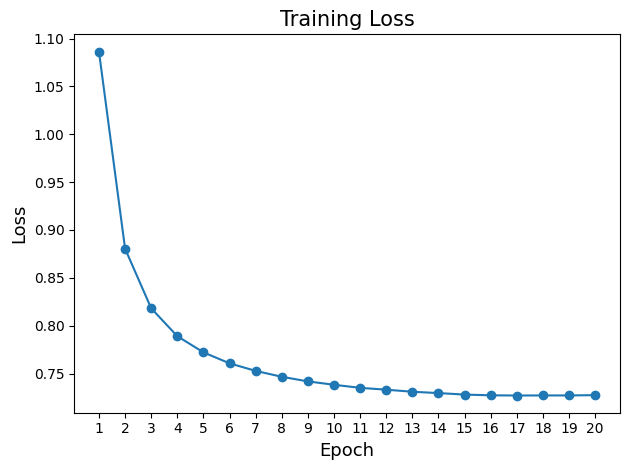

In [17]:
# Plotting the loss
plt.plot(np.arange(1,21,1),loss_train,marker='o')
plt.xticks(np.arange(1,21,1))
plt.xlabel("Epoch",size=13)
plt.ylabel("Loss",size=13)
plt.title("Training Loss",size=15)
plt.tight_layout()

In [18]:
# Using torch categorical function
torch.manual_seed(44)
logits=torch.tensor([1.0,1.0,1.0])
print("Probabilities", nn.functional.softmax(logits,dim=0).numpy())
# Creating a categorical distribution
m=Categorical(logits=logits)
# Generating 10 samples from categorical distribution
samples=m.sample((10,))
print(samples.numpy())

Probabilities [0.33333334 0.33333334 0.33333334]
[2 1 0 0 2 2 1 2 0 1]


In [23]:
# Using categorical function with different logits
torch.manual_seed(11)
weight=torch.tensor([1.0,1.0,3.0])
# Printing probabilities
print("Probabilities",nn.functional.softmax(weight,dim=0).numpy())
# Using torch multinomial here instead
samples=torch.multinomial(weight,10,replacement=True) # returns tensor
samples=samples.numpy()
print(samples)

Probabilities [0.10650698 0.10650698 0.78698605]
[0 2 2 2 2 0 0 0 2 2]
